# Análisis Exploratorio de Datos (EDA)
## Generador de Reportes de Partidos de Fútbol — Premier League
Este notebook explora el dataset crudo para comprender su estructura, 
identificar patrones y detectar desafíos en los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv("../data/raw/Matches.csv")
df_epl = df_raw[df_raw['Division'] == 'E0'].copy()
df_epl['MatchDate'] = pd.to_datetime(df_epl['MatchDate'])

print(f"Partidos totales Premier League: {df_epl.shape[0]}")
print(f"Período: {df_epl['MatchDate'].min().date()} → {df_epl['MatchDate'].max().date()}")
print(f"Columnas: {df_epl.shape[1]}")

Partidos totales Premier League: 9410
Período: 2000-08-19 → 2025-05-25
Columnas: 48


C:\Users\benja\AppData\Local\Temp\ipykernel_28716\4042362997.py:5: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../data/raw/Matches.csv")


## Valores nulos por columna

In [2]:
nulos = df_epl.isnull().sum()
nulos_pct = (nulos / len(df_epl) * 100).round(1)
pd.DataFrame({'Nulos': nulos, '%': nulos_pct})[nulos > 0]

,Nulos,%
MatchTime,7130,75.8
HomeElo,1,0.0
AwayElo,1,0.0
OddHome,83,0.9
OddDraw,83,0.9
OddAway,83,0.9
MaxHome,1810,19.2
MaxDraw,1810,19.2
MaxAway,1810,19.2
Over25,1810,19.2


## Distribución de resultados

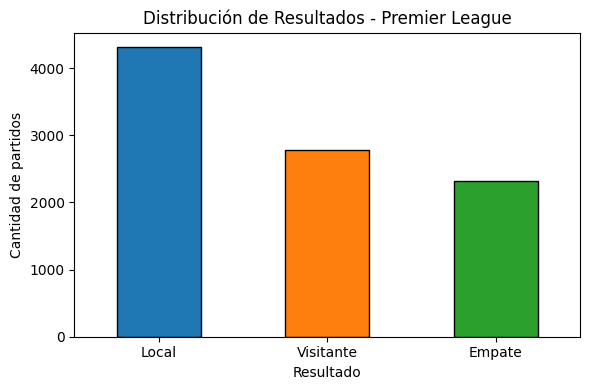

FTResult
Local        4310
Visitante    2782
Empate       2318
Name: count, dtype: int64


In [3]:
resultado_map = {'H': 'Local', 'D': 'Empate', 'A': 'Visitante'}
conteo = df_epl['FTResult'].map(resultado_map).value_counts()

plt.figure(figsize=(6,4))
conteo.plot(kind='bar', color=['#1f77b4','#ff7f0e','#2ca02c'], edgecolor='black')
plt.title('Distribución de Resultados - Premier League')
plt.xlabel('Resultado')
plt.ylabel('Cantidad de partidos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(conteo)

## Estadísticas descriptivas de las columnas numéricas clave

In [4]:
cols_stats = ['FTHome', 'FTAway', 'HomeShots', 'AwayShots',
              'HomeTarget', 'AwayTarget', 'HomeYellow', 'AwayYellow',
              'HomeRed', 'AwayRed', 'HomeCorners', 'AwayCorners']

df_epl[cols_stats].describe().round(2)

,FTHome,FTAway,HomeShots,AwayShots,HomeTarget,AwayTarget,HomeYellow,AwayYellow,HomeRed,AwayRed,HomeCorners,AwayCorners
count,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00,9410.00
mean,1.53,1.18,13.62,10.82,5.97,4.69,1.47,1.79,0.06,0.09,6.04,4.77
std,1.30,1.16,5.36,4.70,3.27,2.75,1.22,1.29,0.25,0.29,3.11,2.75
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,10.00,7.00,4.00,3.00,1.00,1.00,0.00,0.00,4.00,3.00
50%,1.00,1.00,13.00,10.00,6.00,4.00,1.00,2.00,0.00,0.00,6.00,4.00
75%,2.00,2.00,17.00,14.00,8.00,6.00,2.00,3.00,0.00,0.00,8.00,6.00
max,9.00,9.00,43.00,37.00,24.00,20.00,7.00,9.00,3.00,2.00,20.00,19.00


## Goles por temporada

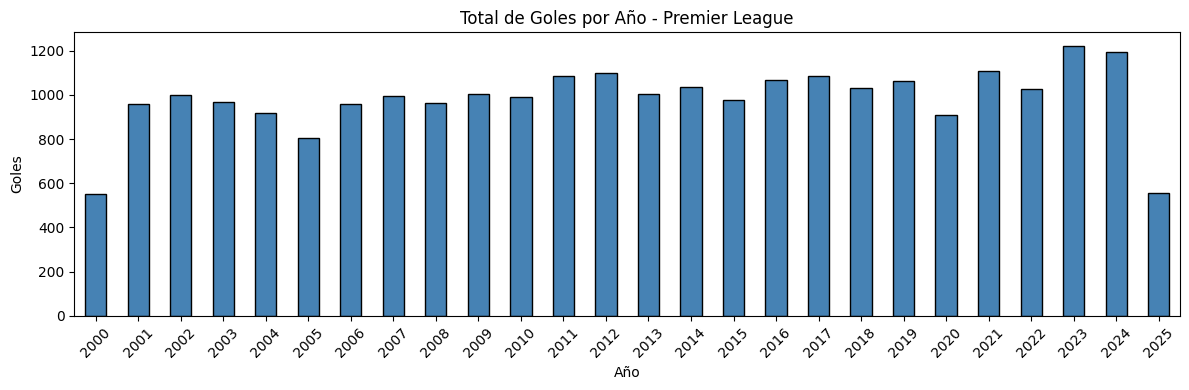

In [5]:
df_epl['Season'] = df_epl['MatchDate'].dt.year
goles_por_año = df_epl.groupby('Season')[['FTHome','FTAway']].sum()
goles_por_año['Total'] = goles_por_año['FTHome'] + goles_por_año['FTAway']

plt.figure(figsize=(12,4))
goles_por_año['Total'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total de Goles por Año - Premier League')
plt.xlabel('Año')
plt.ylabel('Goles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Equipos con más partidos como local

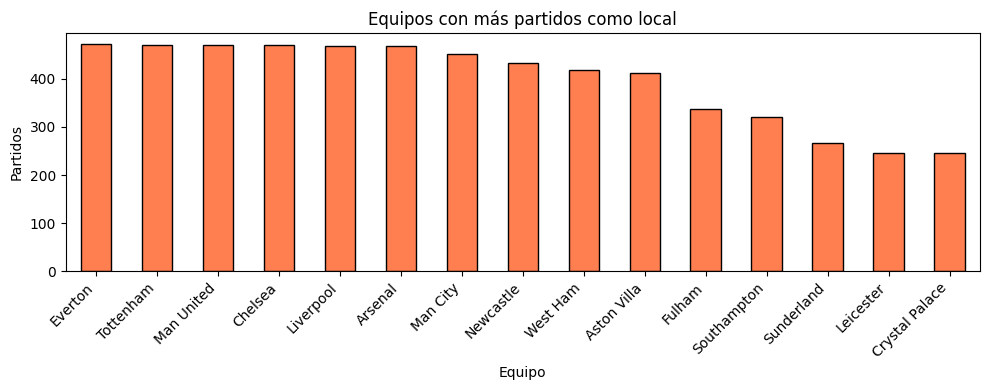

In [6]:
top_equipos = df_epl['HomeTeam'].value_counts().head(15)

plt.figure(figsize=(10,4))
top_equipos.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Equipos con más partidos como local')
plt.xlabel('Equipo')
plt.ylabel('Partidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()